In [39]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [40]:
path_location = r"C:\Users\rajeshkumar.t\Desktop\tranctions.csv"
df = pd.read_csv(path_location)


In [8]:
print(df.head(1))
print(df.isnull().sum())
##df_cleaned = df.dropna()

   transaction_yr  transaction_mth  transaction_wk transaction_dt  \
0            2026                4              14     2026-04-01   

  transaction_status transaction_source live_response_code payment_instrument  \
0             FAILED             iOSApp                NaN              DEBIT   

  bank_code hyp_flag  ... pg_id flipkart_emi_flag marketplace_context  \
0     KOTAK   Others  ...   NaN                No            FLIPKART   

  is_shopsy_order emi_flag adonc_flag count_of_tx acct_cnt tot_amt  \
0             NaN      NaN   No adonc           1        1     329   

  tot_eff_amt_paymnt  
0                329  

[1 rows x 24 columns]
transaction_yr              0
transaction_mth             0
transaction_wk              0
transaction_dt              0
transaction_status          0
transaction_source       5448
live_response_code      98399
payment_instrument          0
bank_code               17025
hyp_flag                    0
asp_flag                    0
merchant_id

In [9]:
##print(df.isnull().sum())
print(df.dtypes)

transaction_yr          int64
transaction_mth         int64
transaction_wk          int64
transaction_dt         object
transaction_status     object
transaction_source     object
live_response_code     object
payment_instrument     object
bank_code              object
hyp_flag               object
asp_flag               object
merchant_id            object
merchant_status        object
marketplace_id         object
pg_id                  object
flipkart_emi_flag      object
marketplace_context    object
is_shopsy_order        object
emi_flag               object
adonc_flag             object
count_of_tx             int64
acct_cnt                int64
tot_amt                 int64
tot_eff_amt_paymnt      int64
dtype: object


In [41]:
df['transaction_dt'] = df['transaction_dt'].astype("datetime64[ns]")
df = df.sort_values('transaction_dt').reset_index(drop=True)

In [42]:
print(df.dtypes)

transaction_yr                  int64
transaction_mth                 int64
transaction_wk                  int64
transaction_dt         datetime64[ns]
transaction_status             object
transaction_source             object
live_response_code             object
payment_instrument             object
bank_code                      object
hyp_flag                       object
asp_flag                       object
merchant_id                    object
merchant_status                object
marketplace_id                 object
pg_id                          object
flipkart_emi_flag              object
marketplace_context            object
is_shopsy_order                object
emi_flag                       object
adonc_flag                     object
count_of_tx                     int64
acct_cnt                        int64
tot_amt                         int64
tot_eff_amt_paymnt              int64
dtype: object


In [43]:
df['count_of_tx'] = pd.to_numeric(df['count_of_tx'], errors= 'coerce')

In [44]:
print(df.dtypes)

transaction_yr                  int64
transaction_mth                 int64
transaction_wk                  int64
transaction_dt         datetime64[ns]
transaction_status             object
transaction_source             object
live_response_code             object
payment_instrument             object
bank_code                      object
hyp_flag                       object
asp_flag                       object
merchant_id                    object
merchant_status                object
marketplace_id                 object
pg_id                          object
flipkart_emi_flag              object
marketplace_context            object
is_shopsy_order                object
emi_flag                       object
adonc_flag                     object
count_of_tx                     int64
acct_cnt                        int64
tot_amt                         int64
tot_eff_amt_paymnt              int64
dtype: object


In [45]:
df=df.sort_values(by=['transaction_dt'])

In [46]:
print(df.head(5))

       transaction_yr  transaction_mth  transaction_wk transaction_dt  \
0                2026                4              14     2026-04-01   
32902            2026                4              14     2026-04-01   
32903            2026                4              14     2026-04-01   
32904            2026                4              14     2026-04-01   
32905            2026                4              14     2026-04-01   

      transaction_status transaction_source live_response_code  \
0                 FAILED             iOSApp                NaN   
32902            SUCCESS             iOSApp            SUCCESS   
32903             FAILED             iOSApp      USER_DROP_OFF   
32904            SUCCESS         MobileSite            SUCCESS   
32905            SUCCESS         AndroidApp            SUCCESS   

      payment_instrument bank_code hyp_flag  ...        pg_id  \
0                  DEBIT     KOTAK   Others  ...          NaN   
32902                COD       NaN

In [47]:
df[df['is_shopsy_order'].isna()]

,transaction_yr,transaction_mth,transaction_wk,transaction_dt,transaction_status,transaction_source,live_response_code,payment_instrument,bank_code,hyp_flag,...,pg_id,flipkart_emi_flag,marketplace_context,is_shopsy_order,emi_flag,adonc_flag,count_of_tx,acct_cnt,tot_amt,tot_eff_amt_paymnt
0,2026,4,14,2026-04-01,FAILED,iOSApp,NaN,DEBIT,KOTAK,Others,...,NaN,No,FLIPKART,NaN,NaN,No adonc,1,1,329,329
32903,2026,4,14,2026-04-01,FAILED,iOSApp,USER_DROP_OFF,EMI,CANARA,Others,...,payu_emi_pg,No,FLIPKART,NaN,3_p,No adonc,2,1,18794,18230
32908,2026,4,14,2026-04-01,FAILED,AndroidApp,USER_DROP_OFF,UPI_INTENT,PAYTM,HYP,...,payu_intent_HL,No,HYPERLOCAL,NaN,NaN,No adonc,1146,1044,1540077,1540077
32909,2026,4,14,2026-04-01,SUCCESS,NaN,SUCCESS,CREDIT,INDUSIND,Others,...,paytm_3ds_tra_cc_dc,No,NaN,NaN,NaN,No adonc,1,1,5887,5887
32913,2026,4,14,2026-04-01,FAILED,AndroidApp,NaN,EMI,HDFC,Others,...,NaN,No,HYPERLOCAL,NaN,3_p,No adonc,67,12,1710763,1692058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537100,2026,4,16,2026-04-12,SUCCESS,AndroidApp,SUCCESS,CREDIT,ICICI,Others,...,razorpay_3ds,No,FLIPKART,NaN,NaN,No adonc,1,1,22804,19754
537101,2026,4,16,2026-04-12,SUCCESS,MobileSite,SUCCESS,CREDIT,SBI,Others,...,paytm_ivr_cc,No,FLIPKART,NaN,NaN,No adonc,1,1,178,178
537102,2026,4,16,2026-04-12,FAILED,AndroidApp,INSUFFICIENT_FUNDS,UPI_INTENT,DEFAULT,Others,...,payu_intent,No,FLIPKART,NaN,NaN,No adonc,1,1,2407,2407
537104,2026,4,16,2026-04-12,FAILED,AndroidApp,INSUFFICIENT_FUNDS,UPI_INTENT,PAYTM,Others,...,payu_intent,No,FLIPKART,NaN,NaN,No adonc,1,1,1005,1005


In [48]:
df['is_shopsy_order'] = df['is_shopsy_order'].fillna("others")

In [49]:
#df[df['is_shopsy_order'].isna()]
print(len(df['is_shopsy_order'].unique()))
print(df['is_shopsy_order'].value_counts())

3
is_shopsy_order
others    265588
False     253277
True       24739
Name: count, dtype: int64


In [50]:
##print(df.describe)
#print(len(df.columns))

In [51]:
#import missingno as msno
#import matplotlib.pyplot as plt

import missingno as msno
import matplotlib.pyplot as plt

<Axes: >

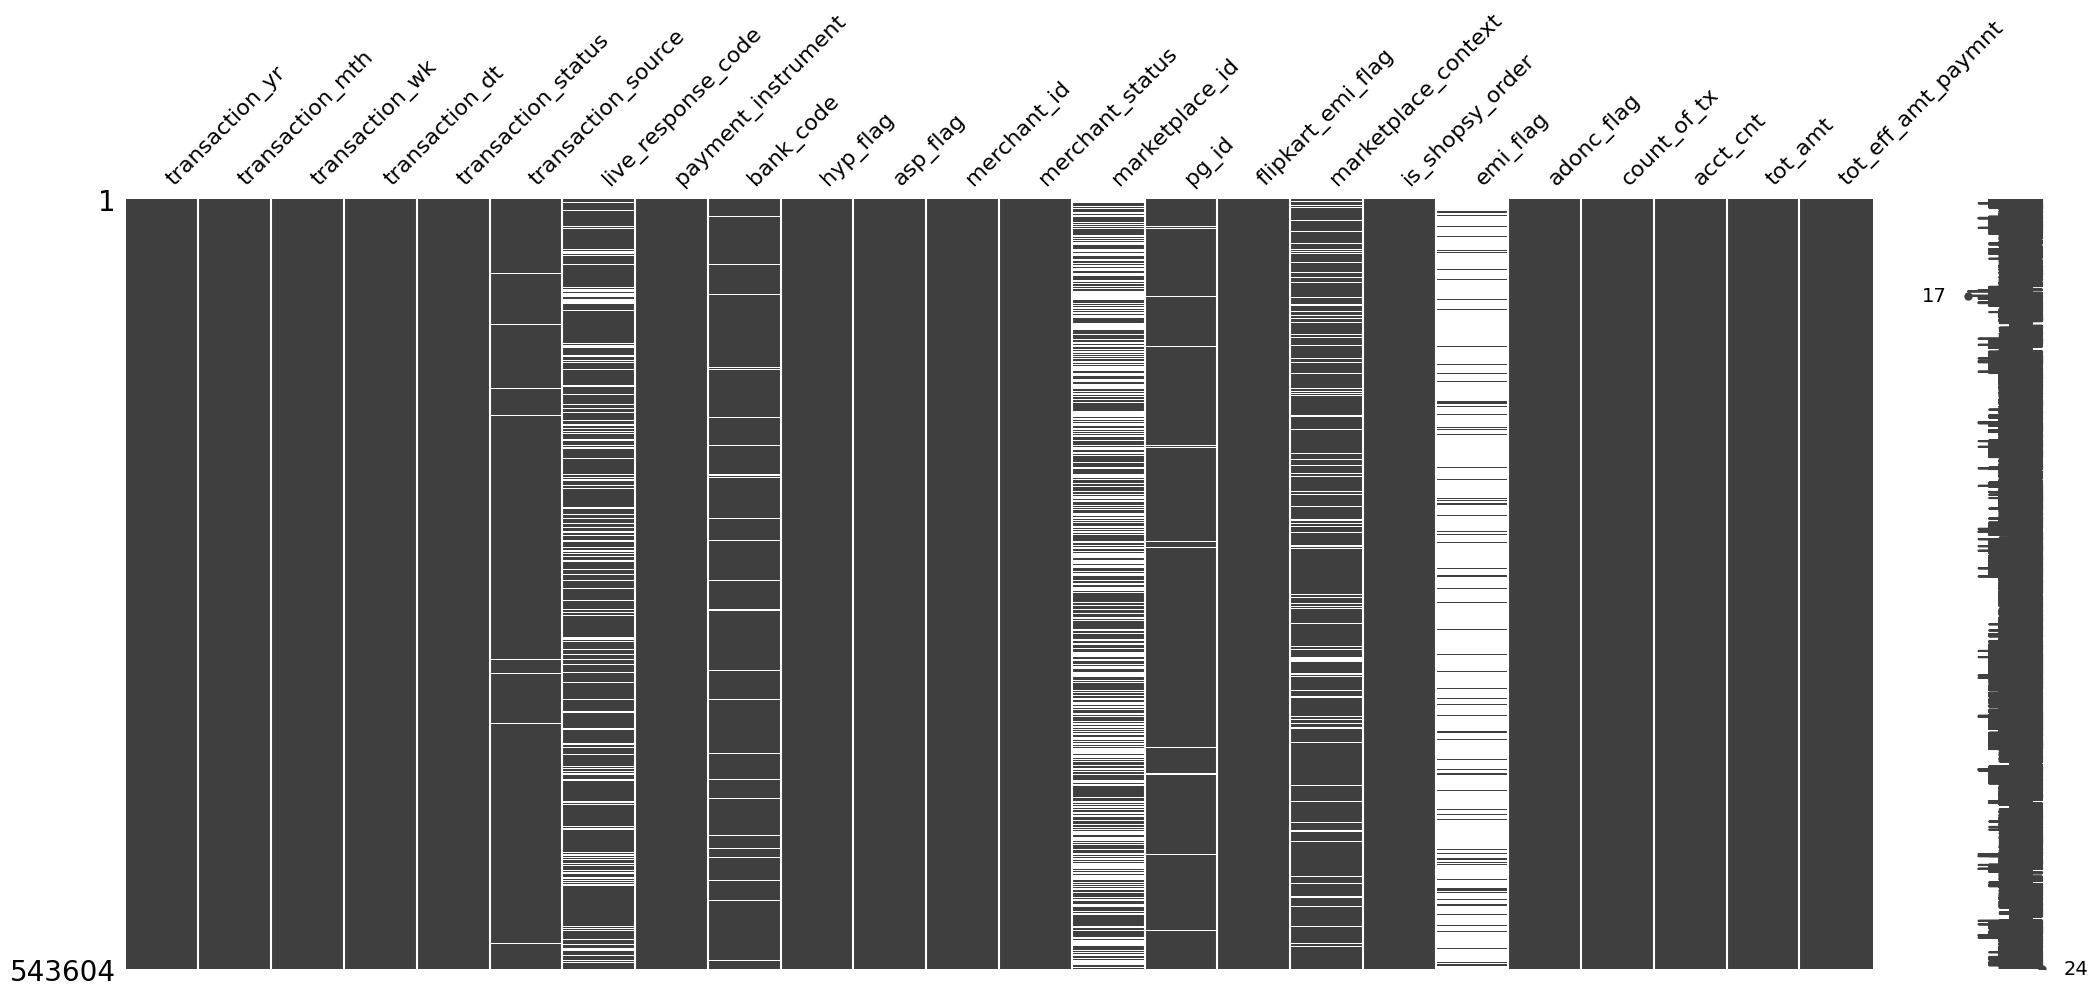

In [52]:
#plt.figure(figsize=(10,5))
msno.matrix(df)
#msno.matrix(df)
#plt.show()

In [53]:
from sklearn.preprocessing import LabelEncoder

num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(-1)

cat_cols = df.select_dtypes(include=['object', 'category','bool']).columns
df[cat_cols] = df[cat_cols].fillna('unknown')

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)



In [56]:

df_clean = df_encoded[df_encoded['count_of_tx'] > 100000].copy()
exclude_cols = ['count_of_tx', 'transaction_dt','merchant_id', 'tot_eff_amt_paymnt','tot_amt','acct_cnt','transaction_mth']
cols_to_drop = [c for c in exclude_cols if  c in df_clean.columns]
X= df_clean.drop(columns=cols_to_drop)
y= df_clean['count_of_tx']

X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression().fit(X_train_scaled,y_train)
importance = pd.DataFrame({'features': X.columns, 'Weight': abs(model.coef_)})
print("---Top 5 drivers")
print(importance.sort_values(by='Weight', ascending=False).head(5))
r_squared = model.score(X_train_scaled,y_train)
print(f"Model Accuracy:{r_squared:.4f}")

---Top 5 drivers
                          features         Weight
11       transaction_source_iOSApp  311677.986843
7    transaction_source_MobileSite  303750.718238
405           is_shopsy_order_True  228054.303773
257                  asp_flag_<500  193443.154056
252                 asp_flag_1k-2k  177326.972003
Model Accuracy:0.7692


In [33]:
df_clean['day_idx'] = np.arange(len(df_clean))
X_time = df_clean[['day_idx']]
y_time = df_clean['count_of_tx']

model_time = LinearRegression().fit(X_time, y_time)
future_days = np.array([[len(df_clean) + i] for i in range(1,8)])
future_forecast = model_time.predict(future_days)
print("\n---Next 7 days forecast")
for i, val in enumerate(future_forecast,1):
    print(f"Day{i}: {val:,.0f}")
                       
                       


---Next 7 days forecast
Day1: 397,293
Day2: 397,463
Day3: 397,633
Day4: 397,803
Day5: 397,973
Day6: 398,144
Day7: 398,314


In [57]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators = 100, random_state= 42).fit(X_train,y_train)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

print("\n top 5 drivers")
print(rf_importance.sort_values(by='Importance', ascending=False).head(5))
print(f"Model Accuracy: {rf_model.score(X_test, y_test):.4f}\n")


 top 5 drivers
                           Feature  Importance
405           is_shopsy_order_True    0.156360
7    transaction_source_MobileSite    0.087023
286                      pg_id_cod    0.086343
257                  asp_flag_<500    0.080253
309                   pg_id_lockin    0.080038
Model Accuracy: 0.9936



In [62]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

time_series_data = df_clean['count_of_tx'].values
arima_model = ARIMA(time_series_data, order=(7,1,1))
arima_result = arima_model.fit()

future_forecast_arima = arima_result.forecast(steps=7)
print("\n next 7 days ARIMA forecast")
for i, val in enumerate(future_forecast_arima,1):
    print(f"Day {i}:{val:,.0f}")


 next 7 days ARIMA forecast
Day 1:408,037
Day 2:399,567
Day 3:421,762
Day 4:365,828
Day 5:379,606
Day 6:383,060
Day 7:391,480


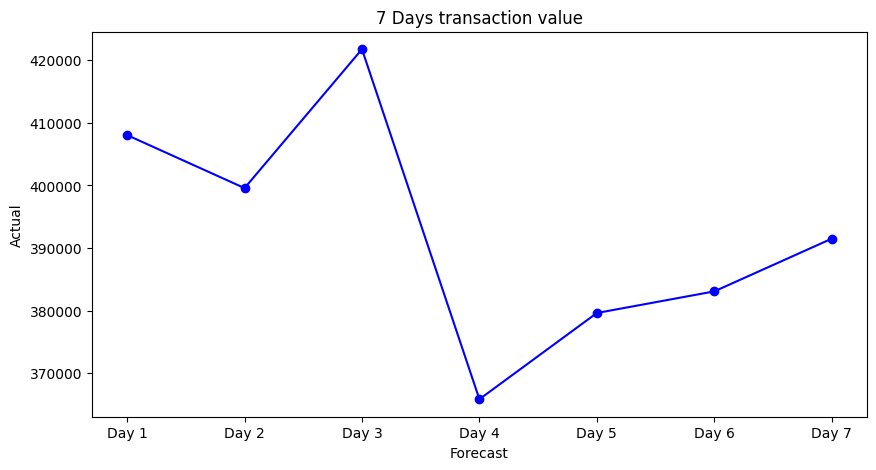

In [63]:
import matplotlib.pyplot as plt
days = ['Day 1', 'Day 2','Day 3', 'Day 4', 'Day 5', 'Day 6', 'Day 7']
plt.figure(figsize=(10,5))
plt.plot(days, future_forecast_arima, marker='o', color='blue')
plt.title("7 Days transaction value")
plt.xlabel("Forecast")
plt.ylabel("Actual")
plt.show()